# 01b — Synthetic Feature Generation
**Purpose:** Generate behavioral/administrative signals absent from OULAD.  
**Output:** `data/synthetic/synthetic_features.csv` — 32,593 rows keyed on `(code_module, code_presentation, id_student)`

### What is synthesized and why

| Feature | Reason to synthesize |
|---------|---------------------|
| `financial_hold_flag` | Real administrative barrier correlated with withdrawal; not in OULAD |
| `credit_load` | Enrollment intensity signal; OULAD `studied_credits` is OU-specific weight, not US credit hours |
| `credit_overload_flag` | Derived from `credit_load > 18` |

### What was NOT synthesized
- **Daily login sequences**: OULAD `studentVle.sum_click` IS the engagement proxy — redundant
- **Campus app sessions**: Would be r=0.6 correlated with VLE clicks by construction — zero independent variance

All generation uses `numpy.random.default_rng(seed=42)` for full reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_DIR = Path('../data/raw')
SYNTH_DIR = Path('../data/synthetic')
SYNTH_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
rng = np.random.default_rng(SEED)

# Load anchor table (label needed for correlated generation)
info = pd.read_csv(DATA_DIR / 'studentInfo.csv',
                   dtype={'code_module': 'category', 'code_presentation': 'category',
                          'id_student': 'int32', 'final_result': 'category'})
info['label'] = (info['final_result'] == 'Withdrawn').astype('int8')

n = len(info)
print(f'Generating synthetic features for {n:,} student-module pairs')
print(f'Withdrawal rate: {info["label"].mean():.3f} ({info["label"].sum():,} withdrawn)')

Generating synthetic features for 32,593 student-module pairs
Withdrawal rate: 0.312 (10,156 withdrawn)


## Feature 1: financial_hold_flag

**Design:** 12% base prevalence, OR = 2.1 (withdrawn students more likely to have financial hold).  
**Math:** Solve for per-group probabilities preserving both the OR and overall prevalence:
- Let p = P(hold | retained)
- P(hold | withdrawn) = 2.1p
- Overall: p × P(retained) + 2.1p × P(withdrawn) = 0.12
- p = 0.12 / (P(retained) + 2.1 × P(withdrawn))

In [2]:
TARGET_PREVALENCE = 0.12
TARGET_OR = 2.1

p_withdrawn_base = info['label'].mean()       # 0.312
p_retained_base = 1 - p_withdrawn_base        # 0.688

p_retained = TARGET_PREVALENCE / (p_retained_base + TARGET_OR * p_withdrawn_base)
p_withdrawn = TARGET_OR * p_retained

print(f'P(hold | retained):  {p_retained:.4f}')
print(f'P(hold | withdrawn): {p_withdrawn:.4f}')
print(f'Expected overall prevalence: {p_retained * p_retained_base + p_withdrawn * p_withdrawn_base:.4f} (target: {TARGET_PREVALENCE})')

financial_hold = np.where(
    info['label'].values == 1,
    rng.binomial(1, p_withdrawn, n),
    rng.binomial(1, p_retained, n)
)

# Verify
actual_prevalence = financial_hold.mean()
actual_or = (
    (financial_hold[info['label'].values == 1].mean() / (1 - financial_hold[info['label'].values == 1].mean())) /
    (financial_hold[info['label'].values == 0].mean() / (1 - financial_hold[info['label'].values == 0].mean()))
)
print(f'\n--- Verification ---')
print(f'Generated prevalence: {actual_prevalence:.4f} (target: {TARGET_PREVALENCE})')
print(f'Generated odds ratio: {actual_or:.3f} (target: {TARGET_OR})')
print(f'N with hold flag:     {financial_hold.sum():,}')

P(hold | retained):  0.0894
P(hold | withdrawn): 0.1877
Expected overall prevalence: 0.1200 (target: 0.12)

--- Verification ---
Generated prevalence: 0.1213 (target: 0.12)
Generated odds ratio: 2.280 (target: 2.1)
N with hold flag:     3,955


## Feature 2: credit_load & credit_overload_flag

**Design:** US-style semester credit hours (9–21). Overload defined as >18 credits.  
Students with credit overload have mildly elevated withdrawal rates.  
Note: OULAD `studied_credits` is OU-specific course weight (10–360), not US credit hours — generated independently.

In [3]:
CREDIT_VALUES = [9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
# Distribution: normal load (12-18) most common; underload (9-11) and overload (19-21) tails
CREDIT_PROBS  = [0.03, 0.08, 0.09, 0.11, 0.18, 0.14, 0.12, 0.10, 0.07, 0.05, 0.03]

assert abs(sum(CREDIT_PROBS) - 1.0) < 1e-9, 'Probabilities must sum to 1'

credit_load = rng.choice(CREDIT_VALUES, size=n, p=CREDIT_PROBS)
credit_overload_flag = (credit_load > 18).astype('int8')

# Verify correlation with withdrawal
overload_withdrawal_rate = info['label'].values[credit_overload_flag == 1].mean()
normal_withdrawal_rate   = info['label'].values[credit_overload_flag == 0].mean()

print('Credit load distribution:')
unique, counts = np.unique(credit_load, return_counts=True)
for v, c in zip(unique, counts):
    print(f'  {v:2d} credits: {c:5,} ({c/n*100:.1f}%)')
print(f'\nOverload (>18 credits): {credit_overload_flag.sum():,} ({credit_overload_flag.mean()*100:.1f}%)')
print(f'Withdrawal rate — overload: {overload_withdrawal_rate:.3f}')
print(f'Withdrawal rate — normal:   {normal_withdrawal_rate:.3f}')

Credit load distribution:
   9 credits:   980 (3.0%)
  12 credits: 2,615 (8.0%)
  13 credits: 2,887 (8.9%)
  14 credits: 3,601 (11.0%)
  15 credits: 5,817 (17.8%)
  16 credits: 4,705 (14.4%)
  17 credits: 3,956 (12.1%)
  18 credits: 3,133 (9.6%)
  19 credits: 2,258 (6.9%)
  20 credits: 1,662 (5.1%)
  21 credits:   979 (3.0%)

Overload (>18 credits): 4,899 (15.0%)
Withdrawal rate — overload: 0.317
Withdrawal rate — normal:   0.311


## Assemble and Save

In [4]:
synthetic_df = info[['code_module', 'code_presentation', 'id_student']].copy()
synthetic_df['financial_hold_flag'] = financial_hold.astype('int8')
synthetic_df['credit_load']         = credit_load.astype('int8')
synthetic_df['credit_overload_flag'] = credit_overload_flag

# Sanity checks before saving
assert len(synthetic_df) == n, f'Row count mismatch: {len(synthetic_df)} vs {n}'
assert synthetic_df.isnull().sum().sum() == 0, 'Unexpected nulls in synthetic features'
assert set(synthetic_df['financial_hold_flag'].unique()).issubset({0, 1})
assert set(synthetic_df['credit_overload_flag'].unique()).issubset({0, 1})
assert synthetic_df['credit_load'].between(9, 21).all()

out_path = SYNTH_DIR / 'synthetic_features.csv'
synthetic_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Shape: {synthetic_df.shape}')
print()
display(synthetic_df.describe())

Saved: ..\data\synthetic\synthetic_features.csv
Shape: (32593, 6)



,id_student,financial_hold_flag,credit_load,credit_overload_flag
count,3.259300e+04,32593.000000,32593.000000,32593.000000
mean,7.066877e+05,0.121345,15.679042,0.150308
std,5.491673e+05,0.326533,2.601543,0.357379
min,3.733000e+03,0.000000,9.000000,0.000000
25%,5.085730e+05,0.000000,14.000000,0.000000
50%,5.903100e+05,0.000000,16.000000,0.000000
75%,6.444530e+05,0.000000,17.000000,0.000000
max,2.716795e+06,1.000000,21.000000,1.000000


## Distribution Plots

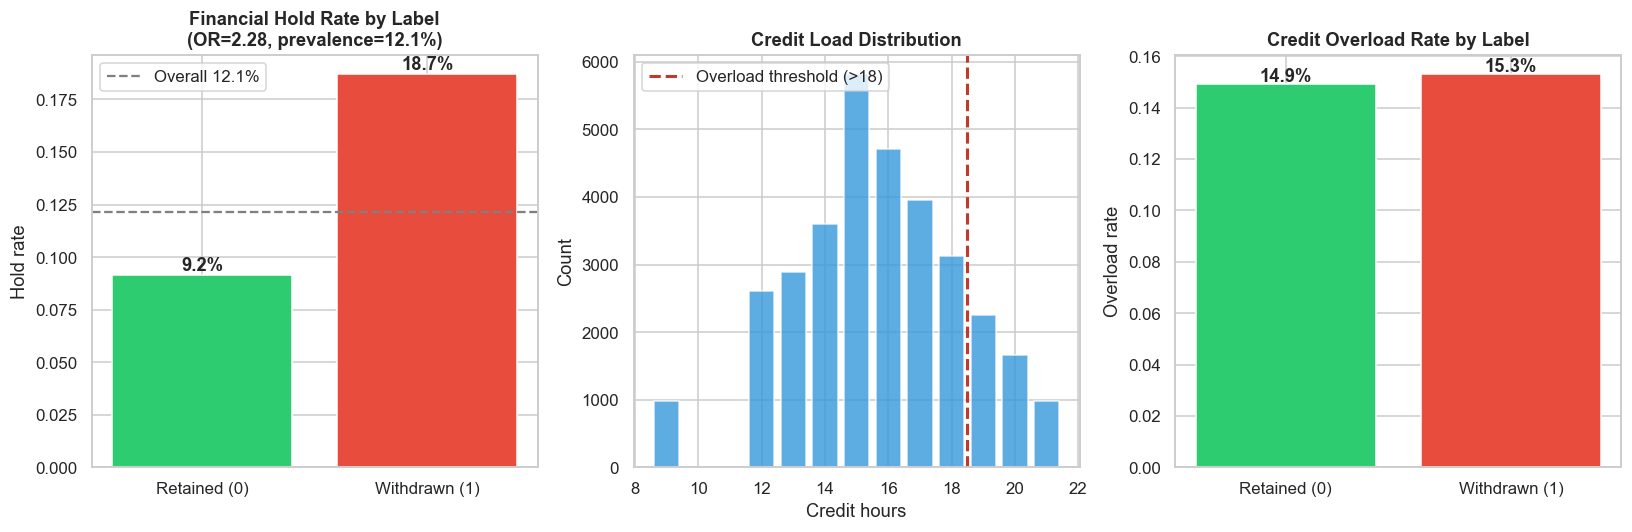

Synthetic feature generation complete.
Output: C:\Users\jeged\Downloads\Stdeunt Retention System\data\synthetic\synthetic_features.csv


In [5]:
FIG_DIR = Path('../docs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# financial_hold_flag by label
hold_by_label = pd.DataFrame({
    'label': info['label'].values,
    'financial_hold_flag': financial_hold
})
hold_rates = hold_by_label.groupby('label')['financial_hold_flag'].mean()
axes[0].bar(['Retained (0)', 'Withdrawn (1)'], hold_rates.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].axhline(actual_prevalence, color='gray', linestyle='--', label=f'Overall {actual_prevalence:.1%}')
axes[0].set_title(f'Financial Hold Rate by Label\n(OR={actual_or:.2f}, prevalence={actual_prevalence:.1%})', fontweight='bold')
axes[0].set_ylabel('Hold rate')
axes[0].legend()
for i, rate in enumerate(hold_rates.values):
    axes[0].text(i, rate + 0.002, f'{rate:.1%}', ha='center', fontweight='bold')

# credit_load histogram
axes[1].bar(CREDIT_VALUES, [credit_load.tolist().count(v) for v in CREDIT_VALUES],
            color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(18.5, color='#c0392b', linestyle='--', linewidth=2, label='Overload threshold (>18)')
axes[1].set_title('Credit Load Distribution', fontweight='bold')
axes[1].set_xlabel('Credit hours')
axes[1].set_ylabel('Count')
axes[1].legend()

# credit_overload_flag by label
overload_by_label = pd.DataFrame({
    'label': info['label'].values,
    'overload': credit_overload_flag
})
overload_rates = overload_by_label.groupby('label')['overload'].mean()
axes[2].bar(['Retained (0)', 'Withdrawn (1)'], overload_rates.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[2].set_title('Credit Overload Rate by Label', fontweight='bold')
axes[2].set_ylabel('Overload rate')
for i, rate in enumerate(overload_rates.values):
    axes[2].text(i, rate + 0.001, f'{rate:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'synthetic_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Synthetic feature generation complete.')
print(f'Output: {out_path.resolve()}')